In [1]:
# Course infrastructure setup:
# `version` is used by the course environment, and `assets` helps locate data files
# packaged with the assignment.
version = "REPLACE_PACKAGE_VERSION"
from mads.lib.path import assets


# Assignment 1: Patterns and Similarity

This is a light-weight assignment to warm you up for following coding exercises. In this assignment, you will load a real-world dataset, execute a few code blocks, and explore the outputs. Through this assignment, you are expected to observe how patterns can be used to characterize certain properties of a data object, how they can be used to build a classifier, and how the similarity between data objects can be used to reveal the clustering structure behind the data. 

Let us look at a dataset where the objects of interest are 14 programming languages. The data is formated so that every column corresponds to a "pattern" about GitHub users who use these programming languages.  To make it more fun, each pattern here is an emoji that programmers use in their issue reports and comments.  Every row of the data corresponds to one of the 14 languages, which consists of the counts of each pattern (emoji) that appeared in the GitHub projects with that language as the primary programming language. 

The following snippet loads the data into a numpy array (x) and maps the names of each programming language to a row index (cidx) and each emoji pattern to a column index (fidx).  Now you may check how many times a given emoji pattern (e.g., "🎉") appears in a given programming language (e.g., "Python").  This pattern alone could tell us some characteristics about the language (or how much the programmers like the language), couldn't it?

In [2]:
import csv
import numpy as np
from mads.lib.path import assets

# Locate the tab-delimited dataset that stores emoji frequencies by language.
filename = assets.find("language_emoji_distri_label.txt")

# Read the file into a list, then convert it to a NumPy array so we can slice it
# by rows/columns more easily.
with open(filename) as f:
    data = csv.reader(f, delimiter='\t')
    data = list(data)
    data = np.array(data)

# The first row contains emoji feature names.
colnames = data[0, 1:]

# The first column of the remaining rows contains the programming language labels.
rownames = data[1:, 0]

# The numeric matrix starts after the header row and header column.
# Each row corresponds to one language and each column corresponds to one emoji.
x = data[1:, 1:]
x = x.astype(float)

# Build a feature index so we can quickly map an emoji to its column position.
fidx = {}
for i in range(colnames.size):
    fidx[colnames[i]] = i

# Build a class index so we can quickly map a language name to its row position.
cidx = {}
for i in range(rownames.size):
    cidx[rownames[i]] = i

print('Object names:', rownames.tolist())
print('Patterns:', colnames.tolist())
print('Data matrix shape:', x.shape)


Object names: ['C#', 'C', 'VimL', 'R', 'Python', 'Ruby', 'C++', 'PHP', 'CSS', 'Go', 'Java', 'JavaScript', 'Perl', 'Shell']
Pattern names (top 10): ['😄' '😉' '✅' '✔' '🎉' '💯' '❤' '👎' '😃' '⚠']
Dimensions of data:  (14, 1271)
How many times pattern 🎉 appears for Python? 417.0


Now that we obtained patterns that represent the characteristics of each programming language, we can utilize them to deliver more powerful data mining functionalities.  One common practice is to use the patterns as "features" for a downstream machine learning task, such as classification.  For example, suppose developers of a GitHub project use emojis "😄, 👊, and 💃" to describe their experience. Which languages are they more likely to be using? Here, every language is interpreted as a "class" and we will assign a new data object ['😄', '👊', '💃'] into the most likely classes. 

To do that, we need to build a so-called "classifier", which is trained using the observed data objects and their pattern/feature vectors. The trained classifier then takes the input of any new pattern/feature vector and outputs its predictions (a ranked list of classes).  We have implemented a very simple classifier for you, and you will see many more complex classifiers in the supervised machine learning class. 

In [3]:
from collections import namedtuple

# The following two helper functions are provided by the assignment.
# They train and apply a very simple Naive Bayes classifier.
# For this assignment, we mainly need to understand how to PREPARE the input
# and how to INTERPRET the output.

def naive_bayes_train(x, classes, features):
    # a very simple naive Bayes classifier 
    # data input: each row is the accumulated feature vector of a class
    # do not use this function when you have access to individual data examples
    x = x + 0.5 
    rowsum = x.sum(axis=1)
    p = x / rowsum[:,np.newaxis]
    logp = np.log(p)
    t = namedtuple('naivebayes', ['classes', 'features', 'logprobs'])
    return t(classes, features, logp)

def naive_bayes_test(model, xx):
    # classify a new test example (xx)
    # xx has to be a binary vector indicating the existence of features in the test example
    z = xx[np.newaxis,:] * model.logprobs
    z = z.sum(axis=1)
    p = np.exp(z)
    p = p / p.sum()
    out = np.zeros(model.classes.size, dtype=[('class', object), ('prob', float), ('logprob', float)])
    out['class'] = model.classes
    out['prob'] = p
    out['logprob'] = z
    return out


In [4]:
# Train the Naive Bayes model using the language-by-emoji matrix.
# Each row is one language, and each column is one emoji feature.
model = naive_bayes_train(x, classes=rownames, features=colnames)

# Example input pattern:
# We want to ask: if a project is described with these emojis,
# which language is most likely?
pattern = ['😄', '👊', '💃']

# Create an all-zero binary feature vector with one position per emoji.
xx = np.zeros(model.features.size)

# Turn on the positions for the emojis that appear in the pattern.
for p in pattern:
    xx[fidx[p]] = 1

# Run the classifier. The output is a structured array containing:
# - the class label
# - the probability
# - the log-probability
prediction = naive_bayes_test(model, xx)

# Sort by log-probability so the most likely classes appear last,
# then reverse to show the top 3 in descending order.
prediction = np.sort(prediction, order='logprob')
topclass = prediction[::-1][0:3]

print('Input pattern:', pattern)
print('Top 3 classes:')
for i in topclass:
    print(i)


Input patterns: ['😄', '👊', '💃']
Most likely language:  Python
Second likely language:  JavaScript
Third likely language:  C#


Do the results make sense to you?  Given the semantics of the three emojis, "😄(happy), 👊(powerful), 💃(dancing)", do you feel good about having Python as the programming language for MADS? 😄😄 You can also try to predict the most likely languages for a different set of pattern, say "❌, 🐛, and 🚀". Do you still see Python among the top 3 classes?  Do you feel even better? 

### Exercise 1 (10 pts)

Complete the following code block to find the most likely language based on the pattern `['❌', '🐛', '🚀']`.

**What the solution does:**
1. Builds a binary feature vector for the new emoji pattern.
2. Uses `naive_bayes_test` to score each language.
3. Selects the language with the highest log-probability.


In [ ]:
new_pattern = ['❌', '🐛', '🚀']

most_likely_language = ""

# Exercise 1 solution:
# Step 1: Create a binary feature vector the same length as the emoji vocabulary.
xx = np.zeros(model.features.size)

# Step 2: Mark the emojis that appear in the new pattern with 1s.
for p in new_pattern:
    xx[fidx[p]] = 1

# Step 3: Use the provided classifier to score every language.
prob = naive_bayes_test(model, xx)

# Step 4: Find the index of the largest log-probability and return the
# corresponding language label.
# We use `prob['logprob']` because the output is a structured array.
most_likely_language = prob['class'][np.argmax(prob['logprob'])].astype(str)

# Display the final answer so it is easy to verify in the notebook.
most_likely_language


In [ ]:
# Hidden test cell for Exercise 1
# The autograder checks whether `most_likely_language` contains the correct answer.


We've shown that "patterns" of data objects can be utilized to build more complex data mining functionalities.  So can similarities/distances.  In the following example, you'll see how we compute the distance between every pair of our data objects (programming languages), and how we can cluster them purely based on the distances.  The following snippet should generate a hierarchy of languages, where more similar languages (based on how people describe them with emojis) are clustered close by.  This structure of hierarchical clusters are called a "dendrogram."  Does it make sense to you that Javascript is closer to Ruby and Python is closer to Java?  

In [ ]:
from scipy.cluster import hierarchy
from scipy.spatial import distance
import matplotlib.pyplot as plt
%matplotlib inline

# Compute the pairwise Euclidean distances between all languages.
# This gives us a compact representation of how similar or different
# the languages are based on their emoji-usage patterns.
dist = distance.pdist(x, 'euclidean')

# Use hierarchical clustering (Ward linkage) to build a tree structure
# from the pairwise distances.
Z = hierarchy.linkage(dist, 'ward')

# Plot the dendrogram so we can visually inspect which languages cluster together.
dn = hierarchy.dendrogram(
    Z,
    labels=rownames,
    orientation='right',
    color_threshold=10000
)

# Languages that merge together at shorter horizontal distances are more similar.


![Screenshot 2026-04-03 203746.png](<attachment:Screenshot 2026-04-03 203746.png>)
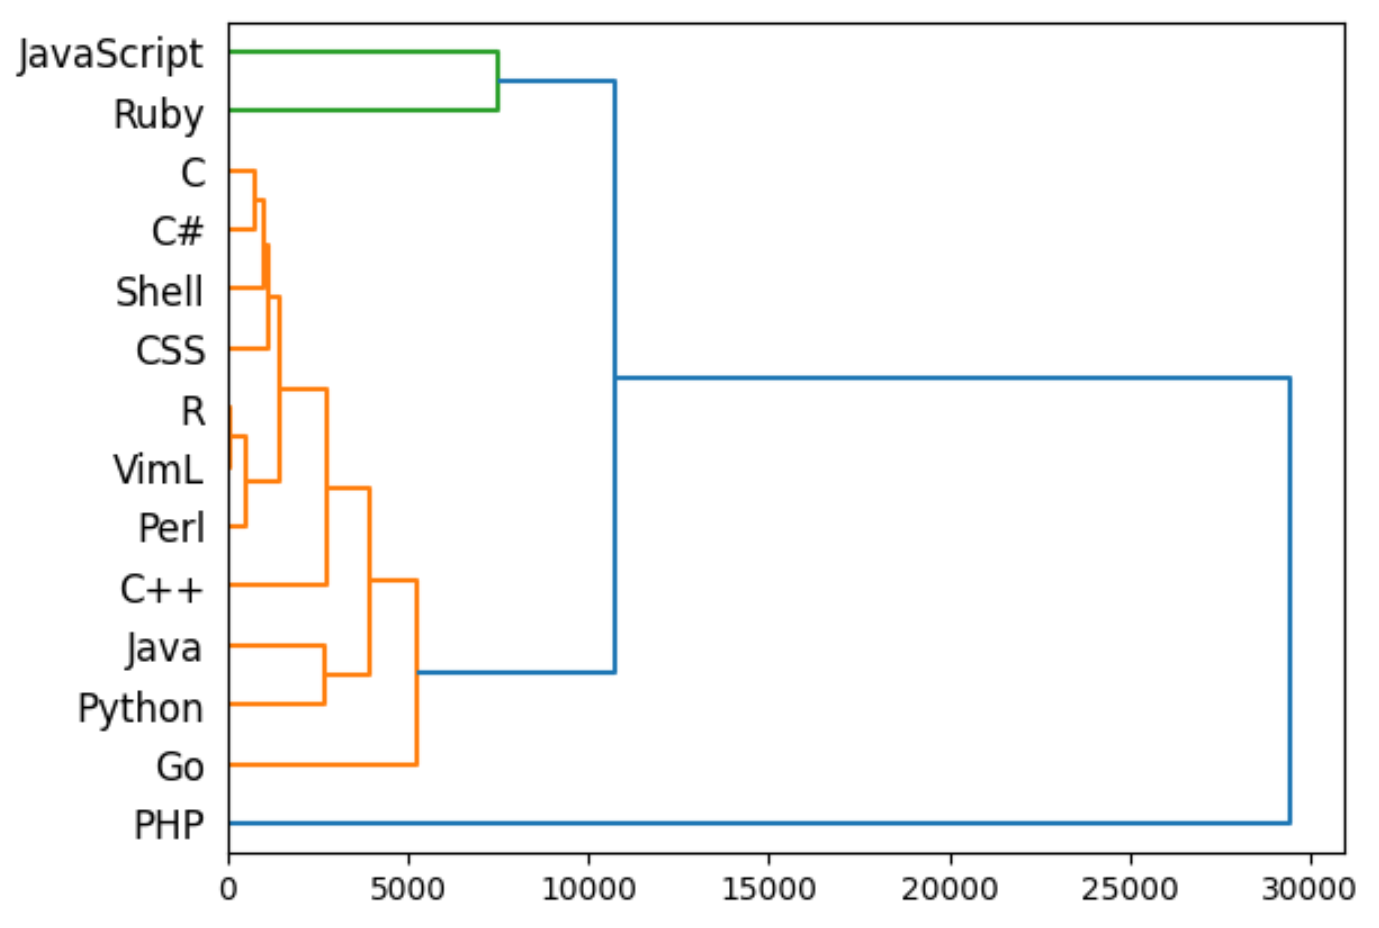

### Exercise 2 (10 pts)

Based on the dendrogram above, identify the language closest to JavaScript.

**How to read the plot:**
- Languages that connect with the shortest branch distance are the closest.
- In this dendrogram, **JavaScript** merges directly with **Ruby** first.


In [ ]:
# From the dendrogram, JavaScript merges first with Ruby,
# so Ruby is the closest language to JavaScript in this clustering.
closest_language = "Ruby"

In [ ]:
# Hidden test cell for Exercise 2
# The autograder checks whether `closest_language` contains the correct answer.
